In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

import sklearn
print("scikit-learn version:", sklearn.__version__)
print("준비 완료!")

scikit-learn version: 1.7.1
준비 완료!


In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')
print("Data shape:", df.shape)
df.head()

Data shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# 어제 선택한 핵심 변수 4개
features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

X = df[features]  # 입력 변수 (4개)
y = df['quality'] # 목표 변수

# 훈련 80% / 테스트 20% 로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("전체 데이터:", len(df))
print("훈련 데이터:", len(X_train))
print("테스트 데이터:", len(X_test))

전체 데이터: 1599
훈련 데이터: 1279
테스트 데이터: 320


In [4]:
# 모델 만들기
model = LinearRegression()

# 훈련 데이터로 학습
model.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred = model.predict(X_test)

# 성능 평가
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== 다중회귀분석 결과 ===")
print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"\n각 변수의 계수:")
for feature, coef in zip(features, model.coef_):
    print(f"  {feature:20s}: {coef:.3f}")
print(f"  절편: {model.intercept_:.3f}")

=== 다중회귀분석 결과 ===
R²: 0.388
RMSE: 0.633

각 변수의 계수:
  alcohol             : 0.311
  volatile acidity    : -1.192
  sulphates           : 0.634
  citric acid         : -0.062
  절편: 2.619


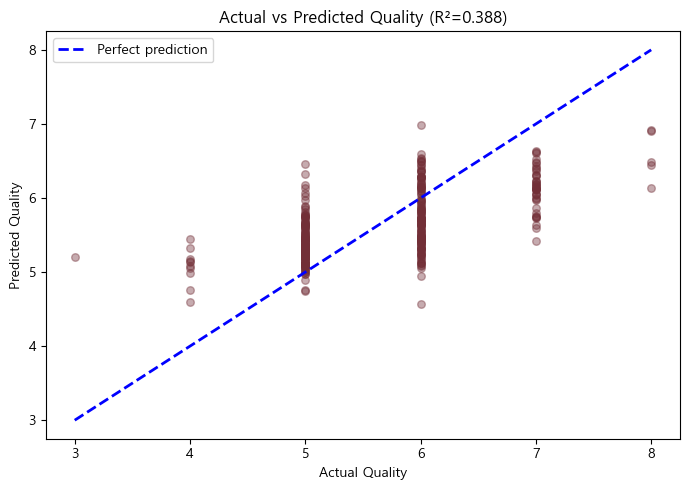

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(y_test, y_pred, color='#722F37', s=30, alpha=0.4)
ax.plot([3, 8], [3, 8], color='blue', linewidth=2,
        linestyle='--', label='Perfect prediction')

ax.set_xlabel('Actual Quality')
ax.set_ylabel('Predicted Quality')
ax.set_title(f'Actual vs Predicted Quality (R²={r2:.3f})')
ax.legend()

plt.tight_layout()
plt.show()